**<span style="font-size:20px; color: LightBlue;">This file is created for Linear SVM modeling</span>**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv('creditcard.csv')

**<span style="font-size:20px; color: LightBlue;">Function to split features and target variable, preprocess data, and return train-test splits</span>**

In [ ]:
# Function to slpit the data into train and test data
def splitFeatureTarget():

    X = df.drop('Class', axis=1)
    y = df['Class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("\n Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("\n Class distribution in train:\n", y_train.value_counts())
    print("\n Class distribution in test:\n", y_test.value_counts())
    return X_train, X_test, y_train, y_test

**<span style="font-size:20px; color: LightBlue;">Function to evaluate model performance using various metrics</span>**

In [20]:
#Function created which performs the following tasks:
#1. Training model to output a prediction for each observation
#2. Evaluating the model performance using accuracy, confusion matrix, and classification report
#3. Printing the model performance metrics
#4. Plotting the confusion matrix

def evaluateModelPerf(model, X_test, y_test):
    # Performing step #1
    y_pred = model.predict(X_test)

    # Performing step #2
    accuracy = accuracy_score(y_test, y_pred)
    #matrix = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Performing step #3
    print("\n Accuracy:", accuracy)
    print("\n Classification Report:\n", report)
    print("\n Confusion Matrix:")

    # Performing step #4
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    disp.figure_.set_size_inches(4, 4)
    plt.show()

**<span style="font-size:20px; color: LightBlue;">Function to create ROC AUC curve for the model</span>**

In [27]:
#Function created which performs the following tasks:
#1. Predicting probabilities of class 1 on model
#2. Calculating ROC curve and AUC using inbuilt functions
#3. Plotting and displaying ROC AUC curve
#4. Creating legend and grid for the plot for better visualization

def createRocAucCurve(model,X_test,y_test):
    
    # Performing step #1
    #y_probability = model.predict_proba(X_test)[:, 1]  
    svm_scores = model.decision_function(X_test)

    #Saving the variable for final model comparisons
    np.save("results/svm_y_prob.npy", svm_scores)

    # Performing step #2
    roc_auc = roc_auc_score(y_test, svm_scores)
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    precision, recall, thresholds = precision_recall_curve(y_test, svm_scores)
    pr_auc = auc(recall, precision)
    print(f"PR AUC: {pr_auc:.4f}")
    
    # Ploting Precision-Recall curve
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (Linear SVM Model) ")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

**<span style="font-size:30px; color: LightBlue;">Implementation of Linear SVM Model</span>**


 Train shape: (227845, 30) Test shape: (56962, 30)

 Class distribution in train:
 Class
0    227451
1       394
Name: count, dtype: int64

 Class distribution in test:
 Class
0    56864
1       98
Name: count, dtype: int64
------------

 Accuracy: 0.9772831010147116

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962


 Confusion Matrix:


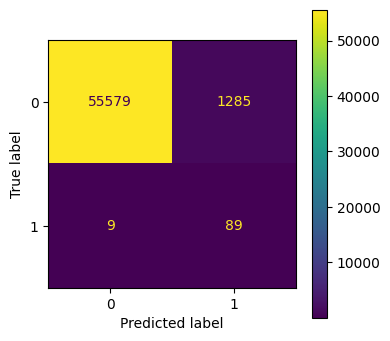

ROC-AUC: 0.9750
PR AUC: 0.7284


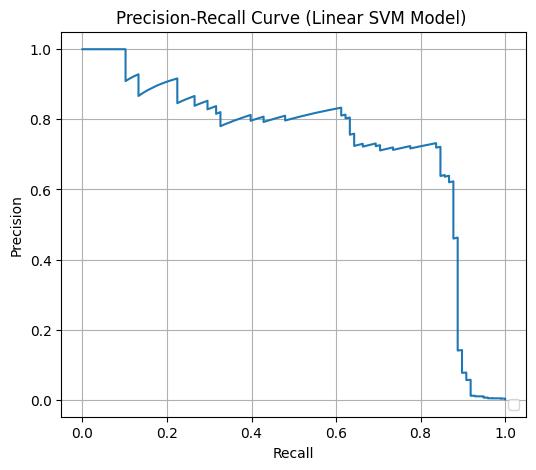

In [28]:
X_train, X_test, y_train, y_test = splitFeatureTarget()

svm_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)

print("------------")
evaluateModelPerf(svm_pipeline, X_test, y_test)


# Calling the function to create ROC AUC curve for the model with L1 regularization
createRocAucCurve(svm_pipeline, X_test, y_test)